<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Generacion_de_una_variable_aleatoria_Poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Generación de una variable aleatoria Poisson:**

Consiste en simular el conteo de eventos que ocurren en un tiempo dado. Los eventos ocurren de manera independiente y está determinada por un solo parámetro: la media $\lambda$.

La función de probabilidad de una variable aleatoria $X \sim Poisson(\lambda)$ es:
$$P(X=i)= e^{-λ} \frac{\lambda^i}{i!} \qquad i=0,1,...$$

Para generar variables aleatorias Poisson utilizamos el método de la transformada inversa:
$$P_{i+1}=\frac{\lambda}{i+1}P_i \qquad i\geq 0$$
Esto permite calcular las probabilidades sin usar factoriales repetidamente, haciendo más eficiente el algoritmo.

In [21]:
# Código: Generación de variables aleatorias Poisson
# ============================================

import random as r #Imortamos las librerías
import math
import matplotlib.pyplot as plt

#Definimos una función
def poisson(lam):

    U = r.random() #Paso 1:Generar U ~ U(0,1)

    i = 0 #Paso 2:Inicializar variables
    p = math.exp(-lam)
    F = p

    while U >= F: #Paso 3 y 4
        p = (lam * p) / (i + 1) #Calcular siguiente probabilidad
        F = F + p #Actualizar acumulada
        i = i + 1 #Incrementar i

    return i

In [22]:
lam = 4 #Parámetro lambda
n = 1000 #Generar muestra

muestra = []
for j in range(n):
    x = poisson(lam)
    muestra.append(x)

#print("Muestra Poisson:") #Podemos imprimir la muestra pero en este caso es muy grande
#print(muestra)

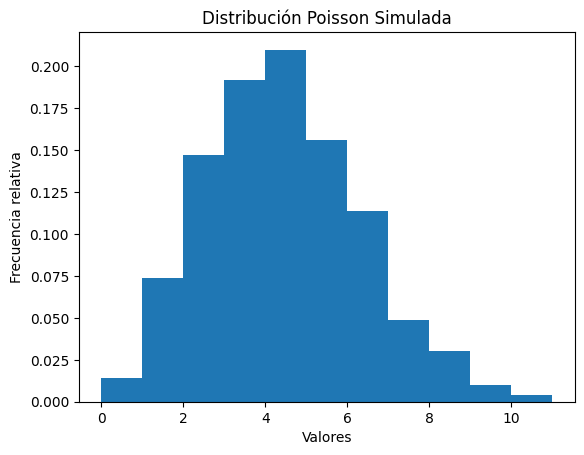

In [23]:
plt.hist(muestra, bins=range(min(muestra), max(muestra)+2),
         density=True)

plt.title("Distribución Poisson Simulada")
plt.xlabel("Valores")
plt.ylabel("Frecuencia relativa")

plt.show()